In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten,Dropout
from tensorflow.keras.layers import Conv2D,MaxPooling2D
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [13]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

In [8]:
from tensorflow.keras.datasets import cifar10
import tensorflow as tf
(X_train,y_train),(X_test,y_test)=cifar10.load_data()
print(X_train.shape)
print(X_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


In [9]:
classes=[
'airplane',
'automobile',
'bird',
'cat',
'deer',
'dog',
'frog',
'horse',
'ship',
'truck'
]
print(classes)
print(np.unique(y_train))

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
[0 1 2 3 4 5 6 7 8 9]


In [10]:
X_train=X_train/255.0
X_test=X_test/255.0

In [11]:
from tensorflow.keras.utils import to_categorical

y_train_cat=to_categorical(y_train,10)
y_test_cat=to_categorical(y_test,10)

print(y_train_cat.shape)

(50000, 10)


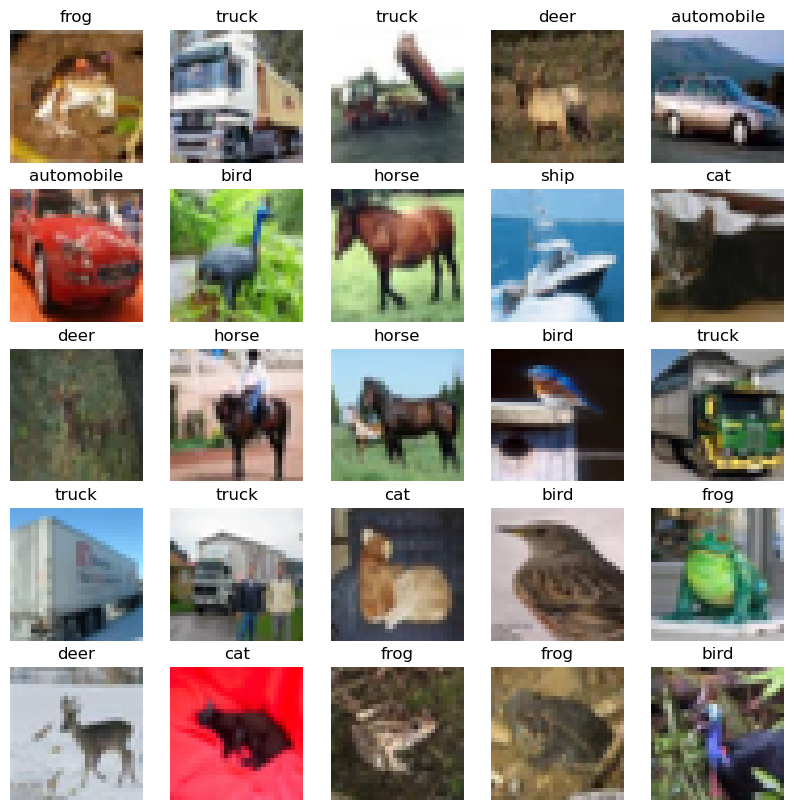

In [14]:
plt.figure(figsize=(10,10))

for i in range(25):

    plt.subplot(5,5,i+1)

    plt.imshow(X_train[i])

    plt.title(classes[y_train[i][0]])

    plt.axis('off')

plt.show()

In [15]:
ann=Sequential([

Flatten(input_shape=(32,32,3)),

Dense(1024,activation='relu'),

Dropout(0.3),

Dense(512,activation='relu'),

Dropout(0.3),

Dense(256,activation='relu'),

Dense(10,activation='softmax')

])

ann.compile(

optimizer='adam',

loss='categorical_crossentropy',

metrics=['accuracy']

)

ann.summary()

/opt/anaconda3/envs/tfmac/lib/python3.10/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,805,450 (14.52 MB)

 Trainable params: 3,805,450 (14.52 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history_ann=ann.fit(
    X_train,
    y_train_cat,
    epochs=20,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.2581 - loss: 2.0336 - val_accuracy: 0.3074 - val_loss: 1.9030
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.3126 - loss: 1.8767 - val_accuracy: 0.3506 - val_loss: 1.8015
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.3294 - loss: 1.8334 - val_accuracy: 0.3512 - val_loss: 1.7737
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.3451 - loss: 1.7928 - val_accuracy: 0.3850 - val_loss: 1.7429
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.3586 - loss: 1.7635 - val_accuracy: 0.3943 - val_loss: 1.7007
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.3672 - loss: 1.7383 - val_accuracy: 0.3913 - val_loss: 1.7127
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.3774 - loss: 1.7225 - val_accuracy: 0.4032 - val_loss: 1.6683
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.3831 - loss: 1.6958 - val_accu

In [17]:
loss,acc=ann.evaluate(
    X_test,
    y_test_cat
)

print("ANN Accuracy:",acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4558 - loss: 1.5571
ANN Accuracy: 0.45579999685287476


In [18]:
y_pred_ann=np.argmax(
ann.predict(X_test),
axis=1
)
print(
classification_report(
y_test,
y_pred_ann
)
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.63      0.39      0.48      1000
           1       0.56      0.63      0.59      1000
           2       0.37      0.18      0.24      1000
           3       0.31      0.26      0.28      1000
           4       0.36      0.43      0.39      1000
           5       0.44      0.29      0.35      1000
           6       0.36      0.73      0.48      1000
           7       0.54      0.47      0.50      1000
           8       0.55      0.66      0.60      1000
           9       0.53      0.52      0.53      1000

    accuracy                           0.46     10000
   macro avg       0.46      0.46      0.45     10000
weighted avg       0.46      0.46      0.45     10000



In [19]:
cnn=Sequential([
Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(32,32,3)
    ),
MaxPooling2D(2,2),
Conv2D(
    64,
    (3,3),
    activation='relu'
    ),
MaxPooling2D(2,2),
Flatten(),
Dense(
    128,
    activation='relu'
),
Dense(
    10,
    activation='softmax'
)
])

cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
    )
cnn.summary()

/opt/anaconda3/envs/tfmac/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
history_cnn=cnn.fit(
    X_train,
    y_train_cat,
    epochs=20,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.4329 - loss: 1.5720 - val_accuracy: 0.5277 - val_loss: 1.3443
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.5642 - loss: 1.2301 - val_accuracy: 0.5930 - val_loss: 1.1839
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.6169 - loss: 1.1009 - val_accuracy: 0.6243 - val_loss: 1.0792
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.6452 - loss: 1.0159 - val_accuracy: 0.6345 - val_loss: 1.0603
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.6758 - loss: 0.9360 - val_accuracy: 0.6639 - val_loss: 0.9710
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.6951 - loss: 0.8793 - val_accuracy: 0.6790 - val_loss: 0.9529
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.7131 - loss: 0.8238 - val_accuracy: 0.6779 - val_loss: 0.9365
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.7329 - loss: 0.7789 - val_accu

In [21]:
loss,acc=cnn.evaluate(
    X_test,
    y_test_cat
)

print("CNN Accuracy:",acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6853 - loss: 1.1909
CNN Accuracy: 0.6852999925613403


In [22]:
deepcnn=Sequential([

Conv2D(
    32,
    3,
    padding='same',
    activation='relu',
    input_shape=(32,32,3)
),
BatchNormalization(),
Conv2D(
    32,
    3,
    activation='relu'
),
MaxPooling2D(),
Dropout(0.25),
Conv2D(
    64,
    3,
    padding='same',
    activation='relu'
),
BatchNormalization(),
Conv2D(
    64,
    3,
    activation='relu'
),
MaxPooling2D(),
Dropout(0.25),
Flatten(),
Dense(
    512,
    activation='relu'
),
Dropout(0.5),
Dense(
    10,
    activation='softmax'
)
])

deepcnn.compile(
    optimizer=Adam(
    learning_rate=0.001
),
loss='categorical_crossentropy',
metrics=['accuracy']
)
deepcnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 15, 15, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,251,242 (4.77 MB)

 Trainable params: 1,251,050 (4.77 MB)

 Non-trainable params: 192 (768.00 B)

In [23]:
early=EarlyStopping(
    patience=5,
    restore_best_weights=True
)
history_deep=deepcnn.fit(
    X_train,
    y_train_cat,
    epochs=50,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early]
)

Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 90ms/step - accuracy: 0.3744 - loss: 1.7524 - val_accuracy: 0.2079 - val_loss: 2.9250
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 92ms/step - accuracy: 0.5199 - loss: 1.3413 - val_accuracy: 0.5470 - val_loss: 1.2512
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 95ms/step - accuracy: 0.5961 - loss: 1.1441 - val_accuracy: 0.6288 - val_loss: 1.0420
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 100ms/step - accuracy: 0.6406 - loss: 1.0133 - val_accuracy: 0.6410 - val_loss: 1.0462
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 109ms/step - accuracy: 0.6763 - loss: 0.9252 - val_accuracy: 0.6722 - val_loss: 0.9363
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 106ms/step - accuracy: 0.6990 - loss: 0.8649 - val_accuracy: 0.7054 - val_loss: 0.8349
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 111ms/step - accuracy: 0.7200 - loss: 0.8024 - val_accuracy: 0.7345 - val_loss: 0.7601
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 99ms/step - accuracy: 0.7343 - loss: 0.758

In [24]:
loss,acc=deepcnn.evaluate(
    X_test,
    y_test_cat
)
print("Deep CNN Accuracy:",acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7874 - loss: 0.6333
Deep CNN Accuracy: 0.7874000072479248


In [ ]:
from tensorflow.keras.applications import EfficientNetB0

base=EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(32,32,3)
)
base.trainable=False
transfer=Sequential([
    base,
    layers.GlobalAveragePooling2D(),
Dense(
    256,
    activation='relu'
),
Dropout(0.3),

Dense(
    10,
    activation='softmax'
)
])
transfer.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
transfer.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 1, 1, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,380,077 (16.71 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [26]:
history_transfer=transfer.fit(
    X_train,
    y_train_cat,
    epochs=20,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 48ms/step - accuracy: 0.0978 - loss: 2.3074 - val_accuracy: 0.1003 - val_loss: 2.3027
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.0970 - loss: 2.3027 - val_accuracy: 0.0952 - val_loss: 2.3027
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - accuracy: 0.1011 - loss: 2.3027 - val_accuracy: 0.0977 - val_loss: 2.3027
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - accuracy: 0.0995 - loss: 2.3027 - val_accuracy: 0.0977 - val_loss: 2.3027
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - accuracy: 0.0981 - loss: 2.3027 - val_accuracy: 0.0977 - val_loss: 2.3027
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - accuracy: 0.0988 - loss: 2.3027 - val_accuracy: 0.0952 - val_loss: 2.3027
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - accuracy: 0.1004 - loss: 2.3027 - val_accuracy: 0.0952 - val_loss: 2.3027
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - accuracy: 0.0995 - loss: 2.3027 - 

In [27]:
loss,acc=transfer.evaluate(
    X_test,
    y_test_cat
)

print("Transfer Accuracy:",acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.1000 - loss: 2.3026
Transfer Accuracy: 0.10000000149011612


In [ ]:
results={
    'ANN':ann.evaluate(
    X_test,
    y_test_cat,
    verbose=0
)[1],

'CNN':cnn.evaluate(
    X_test,
    y_test_cat,
    verbose=0
)[1],

'DeepCNN':deepcnn.evaluate(
    X_test,
    y_test_cat,
    verbose=0
)[1],

'Transfer':transfer.evaluate(
    X_test,
    y_test_cat,
    verbose=0
)[1]
}
results

{'ANN': 0.45579999685287476,
 'CNN': 0.6852999925613403,
 'DeepCNN': 0.7874000072479248,
 'Transfer': 0.10000000149011612}

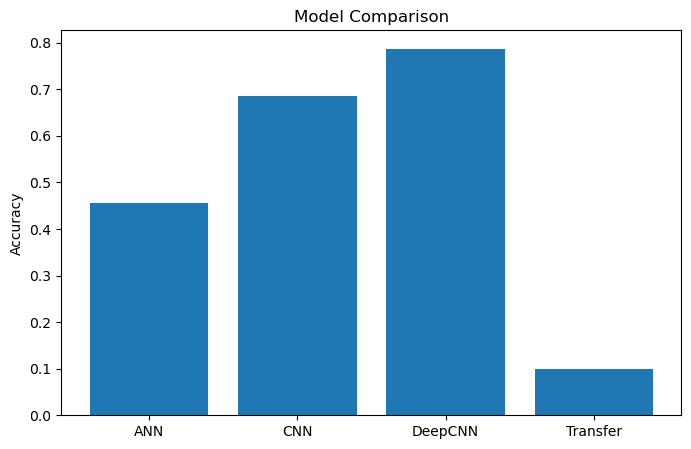

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    results.keys(),
    results.values()
)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()